In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
sia = SentimentIntensityAnalyzer()
test_sentences = [
    "Apple reports record breaking quarterly earnings, stock surges",
    "Apple faces massive lawsuit over patent infringement",
]

print('VADER Output for Test Sentences')
for sentence in test_sentences:
    scores = sia.polarity_scores(sentence)
    print('Sentence :', sentence)
    print('Scores   :', scores)

=== VADER Output for Test Sentences ===

Sentence : Apple reports record breaking quarterly earnings, stock surges
Scores   : {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Sentence : Apple faces massive lawsuit over patent infringement
Scores   : {'neg': 0.5, 'neu': 0.5, 'pos': 0.0, 'compound': -0.6124}
Sentence : Apple releases minor software update
Scores   : {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Sentence : COVID lockdowns shut down economies worldwide
Scores   : {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Sentence : Federal Reserve raises interest rates sharply
Scores   : {'neg': 0.0, 'neu': 0.625, 'pos': 0.375, 'compound': 0.4588}


In [3]:
news = pd.read_csv('stock_news_2016 to 2026.csv', usecols=['date', 'title'])
news['date'] = pd.to_datetime(news['date'])
print('Shape of news dataset:')
print(news.shape)
news.head(2)

Shape of news dataset:
(139919, 2)


,date,title
0,2016-01-01,Lending to foreign step-down arms of Indian fi...
1,2016-01-02,IDBI Bank to raise Rs 900 cr through Basel-III...


In [4]:
sia = SentimentIntensityAnalyzer()
def get_sentiment(headline):
    headline = str(headline)
    scores = sia.polarity_scores(headline)
    return scores['compound']
news['sentiment_score'] = news['title'].apply(get_sentiment)
print('First 5 rows with sentiment scores:')
news[['date', 'title', 'sentiment_score']].head()

First 5 rows with sentiment scores:


,date,title,sentiment_score
0,2016-01-01,Lending to foreign step-down arms of Indian fi...,0.0000
1,2016-01-02,IDBI Bank to raise Rs 900 cr through Basel-III...,0.0000
2,2016-01-02,Forex reserves up $943 mn,0.0000
3,2016-01-02,SBI: Lending rate cut unlikely till end-Mar,-0.2732
4,2016-01-03,"ASK Group to invest Rs 1,500 cr in real estate...",0.0000


Sentiment Score Statistics
Average score : 0.069
Minimum score : -0.962
Maximum score : 0.958
Positive headlines (score > 0) : 54533
Negative headlines(score < 0) : 31922
Neutral  headlines (score = 0) : 53464


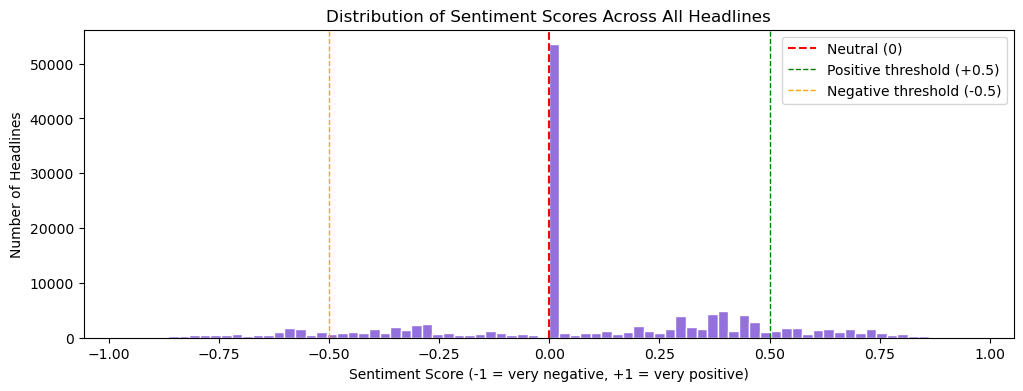

In [5]:
print('Sentiment Score Statistics')
print('Average score :', round(news['sentiment_score'].mean(), 3))
print('Minimum score :', round(news['sentiment_score'].min(), 3))
print('Maximum score :', round(news['sentiment_score'].max(), 3))
# Count how many headlines are positive negative and neutral
positive_count = len(news[news['sentiment_score'] > 0])
negative_count = len(news[news['sentiment_score'] < 0])
neutral_count = len(news[news['sentiment_score'] == 0])
print('Positive headlines (score > 0) :', positive_count)
print('Negative headlines(score < 0) :', negative_count)
print('Neutral  headlines (score = 0) :', neutral_count)

plt.figure(figsize=(12, 4))
plt.hist(news['sentiment_score'], bins=80, color='mediumpurple', edgecolor='white')
plt.axvline(0,    color='red',   linestyle='--', linewidth=1.5, label='Neutral (0)')
plt.axvline(0.5,  color='green', linestyle='--', linewidth=1,   label='Positive threshold (+0.5)')
plt.axvline(-0.5, color='orange',linestyle='--', linewidth=1,   label='Negative threshold (-0.5)')
plt.title('Distribution of Sentiment Scores Across All Headlines')
plt.xlabel('Sentiment Score (-1 = very negative, +1 = very positive)')
plt.ylabel('Number of Headlines')
plt.legend()
plt.savefig('sentiment_distribution.png')

In [6]:
# makef impact tier
def assign_impact_tier(score):
    if score >= 0.5 or score <= -0.5:
        return 'HIGH'
    elif score > 0 or score < 0:
        return 'MEDIUM'
    else:
        return 'LOW'

news['impact_tier'] = news['sentiment_score'].apply(assign_impact_tier)
print('=== Impact Tier Distribution ===')
print(news['impact_tier'].value_counts())

=== Impact Tier Distribution ===
impact_tier
MEDIUM    58962
LOW       53464
HIGH      27493
Name: count, dtype: int64


In [11]:
news.head(5)

,date,title,sentiment_score,impact_tier
0,2016-01-01,Lending to foreign step-down arms of Indian fi...,0.0000,LOW
1,2016-01-02,IDBI Bank to raise Rs 900 cr through Basel-III...,0.0000,LOW
2,2016-01-02,Forex reserves up $943 mn,0.0000,LOW
3,2016-01-02,SBI: Lending rate cut unlikely till end-Mar,-0.2732,MEDIUM
4,2016-01-03,"ASK Group to invest Rs 1,500 cr in real estate...",0.0000,LOW


In [8]:
# Right now we have one row per article
# We need one row per DATE
news_daily = news.groupby('date').agg(
    news_count = ('title', 'count'),
    avg_sentiment = ('sentiment_score', 'mean'),
    max_sentiment = ('sentiment_score', 'max'),
    min_sentiment = ('sentiment_score', 'min'),
    high_impact_count = ('impact_tier', lambda x: (x == 'HIGH').sum()),
    medium_impact_count = ('impact_tier', lambda x: (x == 'MEDIUM').sum()),
    negative_count = ('sentiment_score', lambda x: (x < 0).sum())
).reset_index()
news_daily['avg_sentiment'] = news_daily['avg_sentiment'].round(4)
news_daily['max_sentiment'] = news_daily['max_sentiment'].round(4)
news_daily['min_sentiment'] = news_daily['min_sentiment'].round(4)

print('Shape of daily news features:')
print(news_daily.shape)
news_daily.head(4)

Shape of daily news features:
(3182, 8)


,date,news_count,avg_sentiment,max_sentiment,min_sentiment,high_impact_count,medium_impact_count,negative_count
0,2016-01-01,1,0.0000,0.0000,0.0000,0,0,0
1,2016-01-02,3,-0.0911,0.0000,-0.2732,0,1,1
2,2016-01-03,2,0.0000,0.0000,0.0000,0,0,0
3,2016-01-04,3,0.1872,0.4588,0.0000,0,2,0


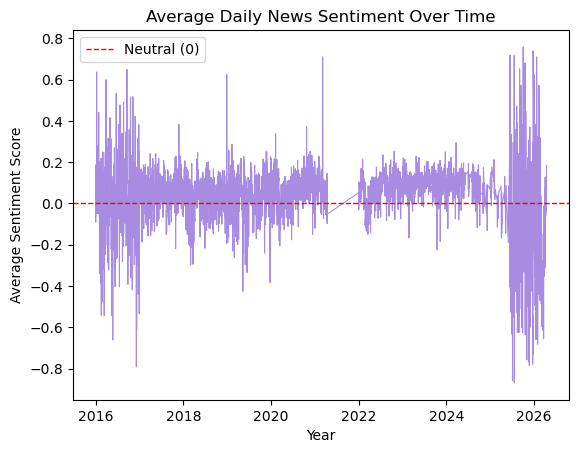

In [9]:
# Plot average sentiment score over time
plt.plot(news_daily['date'], news_daily['avg_sentiment'],
         color='mediumpurple', linewidth=0.8, alpha=0.8)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Neutral (0)')
plt.title('Average Daily News Sentiment Over Time')
plt.xlabel('Year')
plt.ylabel('Average Sentiment Score')
plt.legend()


In [12]:
news_daily.to_csv('news_daily_features.csv', index=False)